In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import glob


# 1. DSSP Scores for all TFs

In [4]:
TF_dssp = pd.read_csv("../output/lambert_TF_AF_dssp.csv", index_col = 0)
TF_dssp

,pos,code,uniprotID
0,0,-,Q9NZC4
1,1,-,Q9NZC4
2,2,-,Q9NZC4
3,3,-,Q9NZC4
4,4,-,Q9NZC4
...,...,...,...
454,454,S,Q8TBJ5
455,455,S,Q8TBJ5
456,456,S,Q8TBJ5
457,457,-,Q8TBJ5


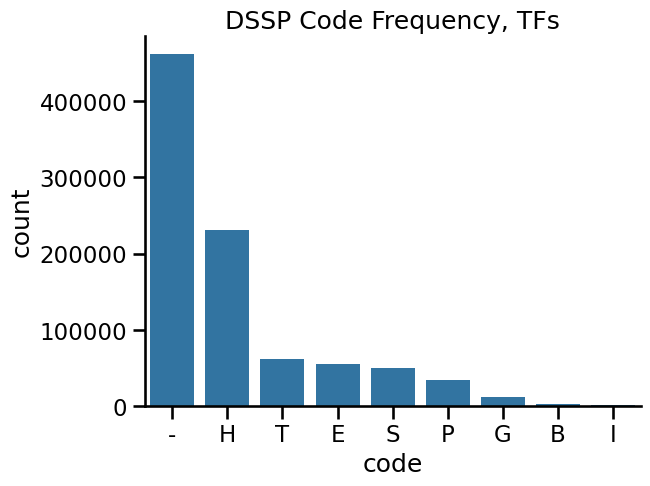

In [ ]:
# G 3-turn helix (3_10 helix)
# H 4-turn helix (alpha-helix)
# I 5-turn helix (pi helix)

# E extended strand in parallel and/or anti-parallel β-sheet conformation. Min length 2 residues
# B residue in isolated β-bridge (single pair β-sheet hydrogen bond formation)

# P Polyproline

# T H-bonded turn
# S bend

# - coil -- ignore

sns.set_context('talk')
sns.barplot(TF_dssp["code"].value_counts())
sns.despine()
plt.title("DSSP Code Frequency, TFs")
plt.show()

# 2. Getting list of DBD positions

In [16]:
lambert_TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
lambert_TFs["uniprotID"] = lambert_TFs["id"].str.split("|").str[1]
lambert_TFs["DBD_coords_merged"] = lambert_TFs["DBD_coords_merged"].str.split("],")
lambert_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[[221, 243, [249, 271, [277, 299, [305, 32...",A0A087WUV0
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[[114, 182, [262, 347]]]",A0AVK6
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[[260, 282, [288, 310, [316, 338, [344, 36...",A0PJY2
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[[1, 330]]]",A1A519
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[[364, 386, [392, 414, [420, 442, [448, 46...",A1YPR0
...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[[31, 83]]]",Q9Y6Q9
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[[165, 187, [193, 215, [221, 243, [249, 27...",Q9Y6R6
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[[583, 596, [1015, 1027, [1450, 1462]]]",Q9Y6X0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[[78, 101, [110, 133, [271, 317, [442, 496...",Q9Y6X8


In [39]:
lambert_TFs_expanded = lambert_TFs.explode("DBD_coords_merged")[["uniprotID", "DBD_coords_merged"]]
lambert_TFs_expanded["Start"] = lambert_TFs_expanded["DBD_coords_merged"].str.extract(r'(\d+),')
lambert_TFs_expanded["End"] = lambert_TFs_expanded["DBD_coords_merged"].str.extract(r', (\d+)')
lambert_TFs_expanded = lambert_TFs_expanded.dropna()
lambert_TFs_expanded["Start"] = lambert_TFs_expanded["Start"].astype(int)
lambert_TFs_expanded["End"] = lambert_TFs_expanded["End"].astype(int)
lambert_TFs_expanded = lambert_TFs_expanded.drop(columns = "DBD_coords_merged")
lambert_TFs_expanded["intervals"] = [np.arange(start, end) for start, end in zip(lambert_TFs_expanded["Start"], lambert_TFs_expanded["End"])]
dbd_positions = lambert_TFs_expanded.explode("intervals")
dbd_positions = dbd_positions[["uniprotID", "intervals"]]
dbd_positions = dbd_positions.rename(columns = {"intervals" : "pos"})
dbd_positions = dbd_positions.reset_index(drop = True)
dbd_positions["DBD"] = True
dbd_positions

,uniprotID,pos,DBD
0,A0A087WUV0,221,True
1,A0A087WUV0,222,True
2,A0A087WUV0,223,True
3,A0A087WUV0,224,True
4,A0A087WUV0,225,True
...,...,...,...
270312,Q9Y6Y1,177,True
270313,Q9Y6Y1,178,True
270314,Q9Y6Y1,179,True
270315,Q9Y6Y1,180,True


# 3. Comparing DBD vs non DBD DSSP scores as a control

In [47]:
TF_dssp_with_dom = pd.merge(TF_dssp, dbd_positions, how = 'left')
TF_dssp_with_dom["DBD"] = TF_dssp_with_dom["DBD"].fillna(False)
display(TF_dssp_with_dom)
TF_dssp_with_dom["DBD"].value_counts()

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_15488/334060667.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  TF_dssp_with_dom["DBD"] = TF_dssp_with_dom["DBD"].fillna(False)


,pos,code,uniprotID,DBD
0,0,-,Q9NZC4,False
1,1,-,Q9NZC4,False
2,2,-,Q9NZC4,False
3,3,-,Q9NZC4,False
4,4,-,Q9NZC4,False
...,...,...,...,...
907792,454,S,Q8TBJ5,False
907793,455,S,Q8TBJ5,False
907794,456,S,Q8TBJ5,False
907795,457,-,Q8TBJ5,False


DBD
False    643672
True     264125
Name: count, dtype: int64

In [48]:
dbd_rows = TF_dssp_with_dom[TF_dssp_with_dom["DBD"]]
display(dbd_rows)
non_dbd_rows = TF_dssp_with_dom[~TF_dssp_with_dom["DBD"]]
display(non_dbd_rows)

,pos,code,uniprotID,DBD
208,208,H,Q9NZC4,True
209,209,H,Q9NZC4,True
210,210,H,Q9NZC4,True
211,211,H,Q9NZC4,True
212,212,H,Q9NZC4,True
...,...,...,...,...
907773,435,H,Q8TBJ5,True
907774,436,H,Q8TBJ5,True
907775,437,H,Q8TBJ5,True
907776,438,H,Q8TBJ5,True


,pos,code,uniprotID,DBD
0,0,-,Q9NZC4,False
1,1,-,Q9NZC4,False
2,2,-,Q9NZC4,False
3,3,-,Q9NZC4,False
4,4,-,Q9NZC4,False
...,...,...,...,...
907792,454,S,Q8TBJ5,False
907793,455,S,Q8TBJ5,False
907794,456,S,Q8TBJ5,False
907795,457,-,Q8TBJ5,False


In [67]:
code_counts = TF_dssp_with_dom.groupby(["DBD", "code"])[["DBD", "code"]].size().reset_index()
code_counts.columns = ['DBD', 'code', 'count']
code_counts

,DBD,code,count
0,False,-,404429
1,False,B,1449
2,False,E,24151
3,False,G,9223
4,False,H,116278
5,False,I,524
6,False,P,28983
7,False,S,27254
8,False,T,31381
9,True,-,56967


In [73]:
code_props = pd.merge(code_counts, code_counts.groupby("DBD").sum().reset_index().drop(columns = "code"), on = "DBD")
code_props["prop"] = code_props["count_x"] / code_props["count_y"]
code_props

,DBD,code,count_x,count_y,prop
0,False,-,404429,643672,0.628315
1,False,B,1449,643672,0.002251
2,False,E,24151,643672,0.037521
3,False,G,9223,643672,0.014329
4,False,H,116278,643672,0.180648
5,False,I,524,643672,0.000814
6,False,P,28983,643672,0.045028
7,False,S,27254,643672,0.042341
8,False,T,31381,643672,0.048753
9,True,-,56967,264125,0.215682


In [78]:
code_props = code_props.sort_values(by = "prop", ascending = False)
code_props

,DBD,code,count_x,count_y,prop
0,False,-,404429,643672,0.628315
13,True,H,113969,264125,0.431496
9,True,-,56967,264125,0.215682
4,False,H,116278,643672,0.180648
11,True,E,30863,264125,0.116850
17,True,T,30349,264125,0.114904
16,True,S,22628,264125,0.085672
8,False,T,31381,643672,0.048753
6,False,P,28983,643672,0.045028
7,False,S,27254,643672,0.042341


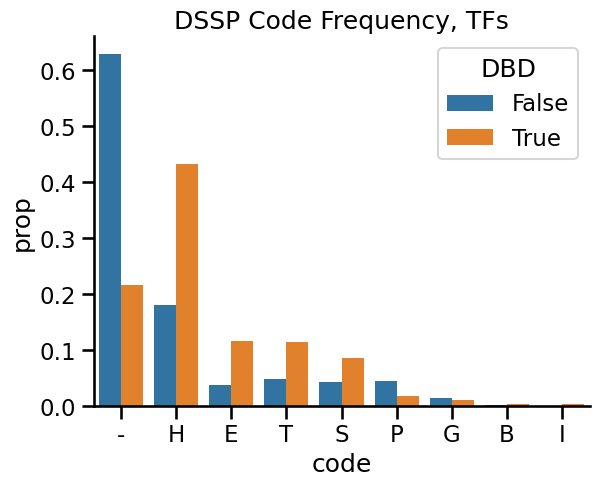

In [ ]:
sns.barplot(x=code_props["code"], y=code_props["prop"], hue = code_props["DBD"])
sns.despine()
plt.title("DSSP Code Frequency, TFs");
# Makes sense - 